# Stay or Switch? Strategic Memory Portability in Competing AI Assistants

**COMSCI/ECON 206 · Problem Set 2 · Phase 2 computational artifact**

This notebook studies when competing AI-assistant platforms voluntarily provide memory portability when each privately observes its own implementation cost. It reports a stylized Bayesian-game benchmark, not empirical estimates or predictions about named firms.

The notebook calls the tested `memory_portability` package. The first code cell regenerates all saved Phase 2 outputs through the same command used in the README.

In [1]:
from pathlib import Path
import subprocess
import sys

working_directory = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate for candidate in (working_directory, working_directory.parent)
    if (candidate / "src" / "memory_portability").is_dir()
)
SOURCE_ROOT = PROJECT_ROOT / "src"
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

run = subprocess.run(
    [sys.executable, str(PROJECT_ROOT / "scripts" / "run_phase2.py")],
    cwd=PROJECT_ROOT,
    check=True,
    capture_output=True,
    text=True,
)
print(run.stdout)

Phase 2 memory-portability regeneration
Python 3.12.14 · arm64 · Darwin
Packages: numpy=2.3.5, pandas=2.2.3, matplotlib=3.10.8, pygambit=16.7.0, nbformat=5.11.1, nbclient=0.11.0
✓ Analytical formulas and benchmark pure/mixed results verified
✓ PyGambit pure equilibria agree with the direct checker
✓ Wrote benchmark JSON, three CSV tables, and two figures
Pure benchmark BNE: [('LL', 'LL'), ('PL', 'PL')]
First grid point with (PL,PL): p=0.60
Benchmark low-type mixed portability probability: 6/7 = 0.8571428571



In [2]:
import json
import pandas as pd
from IPython.display import Image, display

from memory_portability.model import (
    LL, LP, PL, PP, ModelParameters, enumerate_pure_bne,
    enumerate_pure_profile_diagnostics, rival_portability_probability,
    symmetric_low_type_mixed_equilibrium,
)

BENCHMARK = ModelParameters(c_low=0.2, c_high=1.2, p_low=0.7)

## 1. Research question

**When do competing AI assistants voluntarily adopt memory portability when each platform privately knows its own portability implementation cost, and how does portability affect competition for users?**

This phase implements only the first clause: the main Bayesian portability game. User welfare, interventions, auctions, and behavioral evidence remain future work.

## 2. Why this is a Bayesian game

Each platform has a privately observed low or high implementation cost. Both share a common prior over the rival's type and choose actions simultaneously without observing the rival's choice. A strategy must therefore say what a platform would do for every own type. Bayesian Nash equilibrium (BNE), not a fixed complete-information 2×2 Nash calculation, is the relevant baseline concept.

## 3. Players, types, actions, timing, and information

- **Players:** generic Platform A and Platform B.
- **Types:** (c_i\in\{c_L,c_H\}), independently drawn, with (Pr(c_i=c_L)=p).
- **Actions:** (P) (Portable) or (L) (Locked).
- **Timing:** Nature draws types; each platform observes only its own type; both act simultaneously; payoffs are realized.
- **Information:** neither platform observes the rival's type or current action.

This is a static incomplete-information game. The tree used for the optional PyGambit cross-check is a Harsanyi representation, not observed sequential play.

## 4. Payoff model

For platform (i) with own portability cost (c_i):

| Own action / Rival action | Portable | Locked |
|---|---:|---:|
| Portable | (2-c_i) | (-1-c_i) |
| Locked | (1) | (0) |

The payoff numbers are normalized theoretical parameters. They are not empirical estimates of company costs or profits.

## 5. Analytical incentive condition

If the rival chooses Portable with probability (q),

\[
EU(P\mid c_i)=q(2-c_i)+(1-q)(-1-c_i)=3q-1-c_i,
\]

while

\[
EU(L\mid c_i)=q.
\]

Thus Portable is a weak best response exactly when

\[
2q-1\ge c_i.
\]

## 6. Pure type-contingent strategies

The ordering is `(low-type action, high-type action)`:

- `LL`: both types Locked;
- `PL`: low Portable, high Locked;
- `LP`: low Locked, high Portable;
- `PP`: both types Portable.

These are complete Bayesian plans, not realized action profiles.

## 7. Benchmark parameters

The benchmark uses (c_L=0.2), (c_H=1.2), and (p=0.7). These values are normalized parameters chosen for a transparent computational benchmark.

In [3]:
pd.DataFrame(
    {
        "Parameter": ["c_L", "c_H", "p", "Pr(high)"],
        "Value": [BENCHMARK.c_low, BENCHMARK.c_high, BENCHMARK.p_low, 1-BENCHMARK.p_low],
    }
)

,Parameter,Value
0,c_L,0.2
1,c_H,1.2
2,p,0.7
3,Pr(high),0.3


## 8. Direct pure-BNE verification

The authoritative checker evaluates all (4\times4=16) pure strategy profiles. For each profile it tests the prescribed action separately for A-low, A-high, B-low, and B-high. This preserves the type-level incentive constraints rather than comparing only ex-ante utilities of complete plans.

In [4]:
diagnostics = enumerate_pure_profile_diagnostics(BENCHMARK)
diagnostic_table = pd.DataFrame(
    {
        "Strategy A": [row["strategy_A"] for row in diagnostics],
        "Strategy B": [row["strategy_B"] for row in diagnostics],
        "Symmetric": [row["symmetric"] for row in diagnostics],
        "Pure BNE": [row["is_bne"] for row in diagnostics],
        "Maximum profitable deviation": [row["max_deviation_gain"] for row in diagnostics],
        "A expected payoff": [row["expected_payoff_A"] for row in diagnostics],
        "B expected payoff": [row["expected_payoff_B"] for row in diagnostics],
    }
)
display(diagnostic_table.round(6))
print("Pure benchmark BNE:", enumerate_pure_bne(BENCHMARK))

,Strategy A,Strategy B,Symmetric,Pure BNE,Maximum profitable deviation,A expected payoff,B expected payoff
0,LL,LL,True,True,0.0,0.00,0.00
1,LL,PL,False,False,1.2,0.70,-0.84
2,LL,LP,False,False,2.2,0.30,-0.66
3,LL,PP,False,False,2.2,1.00,-1.50
4,PL,LL,False,False,1.2,-0.84,0.70
5,PL,PL,True,True,0.0,0.84,0.84
6,PL,LP,False,False,0.8,-0.12,0.46
7,PL,PP,False,False,0.8,1.56,0.60
8,LP,LL,False,False,2.2,-0.66,0.30
9,LP,PL,False,False,0.8,0.46,-0.12


Pure benchmark BNE: [('LL', 'LL'), ('PL', 'PL')]


In [5]:
best_response_rows = []
for strategy in (LL, PL, LP, PP):
    q = rival_portability_probability(strategy, BENCHMARK.p_low)
    for cost_type, cost in (("Low", BENCHMARK.c_low), ("High", BENCHMARK.c_high)):
        eu_p = 3*q - 1 - cost
        eu_l = q
        best_response_rows.append(
            {"Rival strategy": strategy.name, "q": q, "Own type": cost_type,
             "EU(P)": eu_p, "EU(L)": eu_l,
             "Best response": "P" if eu_p > eu_l else "L" if eu_l > eu_p else "P or L"}
        )
pd.DataFrame(best_response_rows).round(6)

,Rival strategy,q,Own type,EU(P),EU(L),Best response
0,LL,0.0,Low,-1.2,0.0,L
1,LL,0.0,High,-2.2,0.0,L
2,PL,0.7,Low,0.9,0.7,P
3,PL,0.7,High,-0.1,0.7,L
4,LP,0.3,Low,-0.3,0.3,L
5,LP,0.3,High,-1.3,0.3,L
6,PP,1.0,Low,1.8,1.0,P
7,PP,1.0,High,0.8,1.0,L


The direct computation confirms exactly two **pure** BNE, `(LL,LL)` and `(PL,PL)`, and no asymmetric pure BNE at the benchmark. It does not imply that the model has only two BNE of all kinds.

## 9. PyGambit cross-check

The project optionally constructs four joint Nature states with exact rational probabilities and information sets that reveal only each platform's own type. B's information sets also connect nodes following both A actions, preserving simultaneity. The record below reports the actual cross-check status from this execution.

In [6]:
benchmark_record = json.loads((PROJECT_ROOT / "outputs" / "benchmark_verification.json").read_text())
benchmark_record["pygambit_cross_check"]

{'ran': True,
 'available': True,
 'status': 'passed',
 'pure_bne': [['LL', 'LL'], ['PL', 'PL']],
 'agrees_with_direct_checker': True,
 'efg_exported': True,
 'efg_path': 'outputs/memory_portability_benchmark.efg'}

## 10. Symmetric type-specific mixed benchmark

Hold high-cost types at Locked and let a low-cost type choose Portable with probability (x). Then (q=px). Low-type indifference requires

\[
q^*=\frac{1+c_L}{2}=0.6,\qquad
x^*=\frac{q^*}{p}=\frac{6}{7}.
\]

This is the symmetric type-specific mixed equilibrium implied by low-type indifference under the baseline structure. It is distinct from the two pure BNE. It is not an exhaustive mixed-equilibrium claim for every parameterization.

In [7]:
pd.Series(symmetric_low_type_mixed_equilibrium(BENCHMARK), name="Benchmark mixed result")

p                                                                                0.7
q_star                                                                           0.6
x_star                                                                      0.857143
x_star_exact                                                                     6/7
interior_mixed_exists                                                           True
collapses_to_pure_pl                                                           False
high_type_prefers_locked                                                        True
high_type_portability_advantage                                                 -1.0
status                             interior_symmetric_type_specific_mixed_equilib...
formula                                                      x* = (1 + c_low) / (2p)
Name: Benchmark mixed result, dtype: object

## 11. Prior sweep

The formal sweep uses the full-support grid (p=0.01,0.02,\ldots,0.99). It evaluates all 16 profiles at every value. The endpoints (p=0,1) are documented separately because one type has zero probability there.

In [8]:
sweep = pd.read_csv(PROJECT_ROOT / "outputs" / "pure_bne_p_sweep.csv")
bne_rows = sweep[sweep["is_bne"]]
summary = (
    bne_rows.groupby(["strategy_A", "strategy_B"])
    .agg(first_p=("p", "min"), last_p=("p", "max"), grid_points=("p", "size"))
    .reset_index()
)
display(summary)
display(bne_rows[bne_rows["p"].isin([0.59, 0.60, 0.61])])

,strategy_A,strategy_B,first_p,last_p,grid_points
0,LL,LL,0.01,0.99,99
1,PL,PL,0.60,0.99,40


,p,strategy_A,strategy_B,is_bne,symmetric,A_low_action,A_high_action,B_low_action,B_high_action,max_deviation_gain,expected_payoff_A,expected_payoff_B
928,0.59,LL,LL,True,True,L,L,L,L,0.000000e+00,0.0000,0.0000
944,0.60,LL,LL,True,True,L,L,L,L,0.000000e+00,0.0000,0.0000
949,0.60,PL,PL,True,True,P,L,P,L,1.110223e-16,0.6000,0.6000
960,0.61,LL,LL,True,True,L,L,L,L,0.000000e+00,0.0000,0.0000
965,0.61,PL,PL,True,True,P,L,P,L,0.000000e+00,0.6222,0.6222


## 12. Equilibrium-regime figure

Each row is a separate symmetric candidate. Multiple highlighted rows at the same (p) represent equilibrium coexistence; the figure does not select one equilibrium.

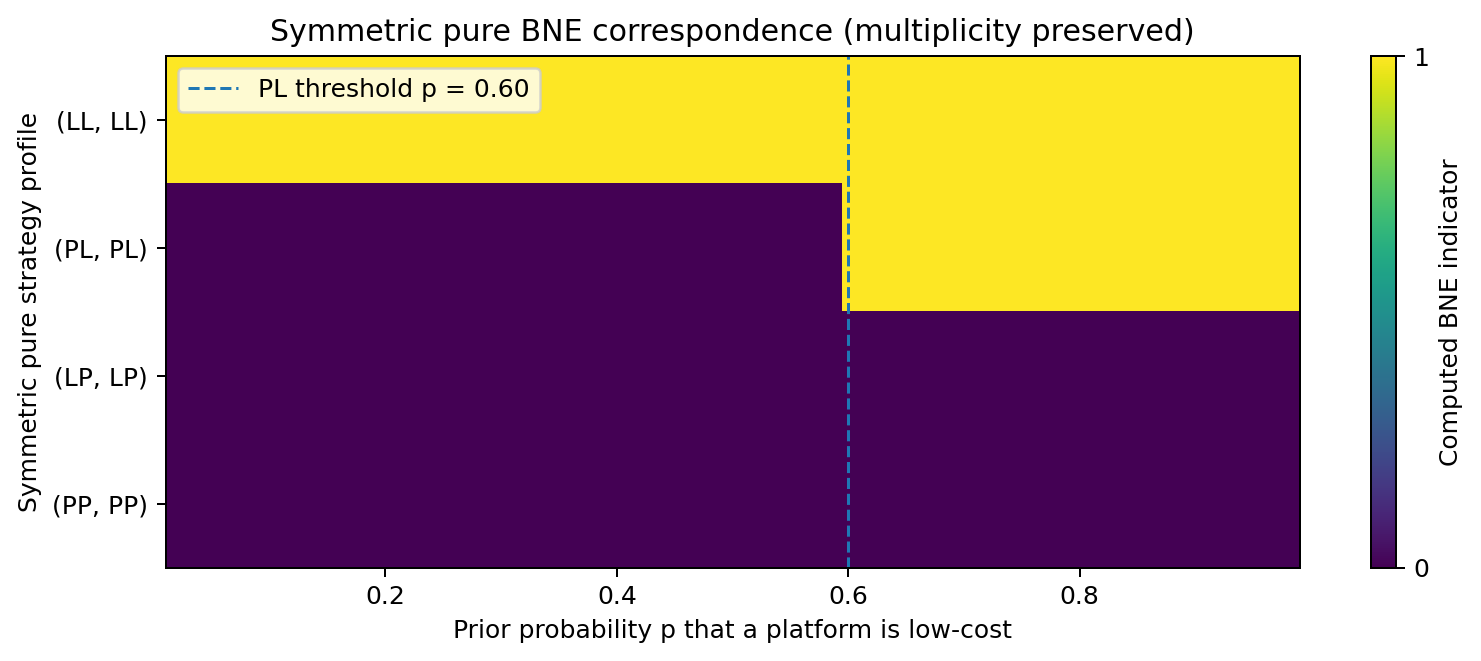

In [9]:
display(Image(filename=str(PROJECT_ROOT / "figures" / "symmetric_pure_bne_by_p.png")))

## 13. Cost/prior sensitivity

The additional sensitivity analysis varies (p) horizontally and (c_L) vertically while holding (c_H=1.2). The computational classification is compared with the analytical boundary (p=(1+c_L)/2).

Grid rows: 2376
Computational/analytical agreement: True


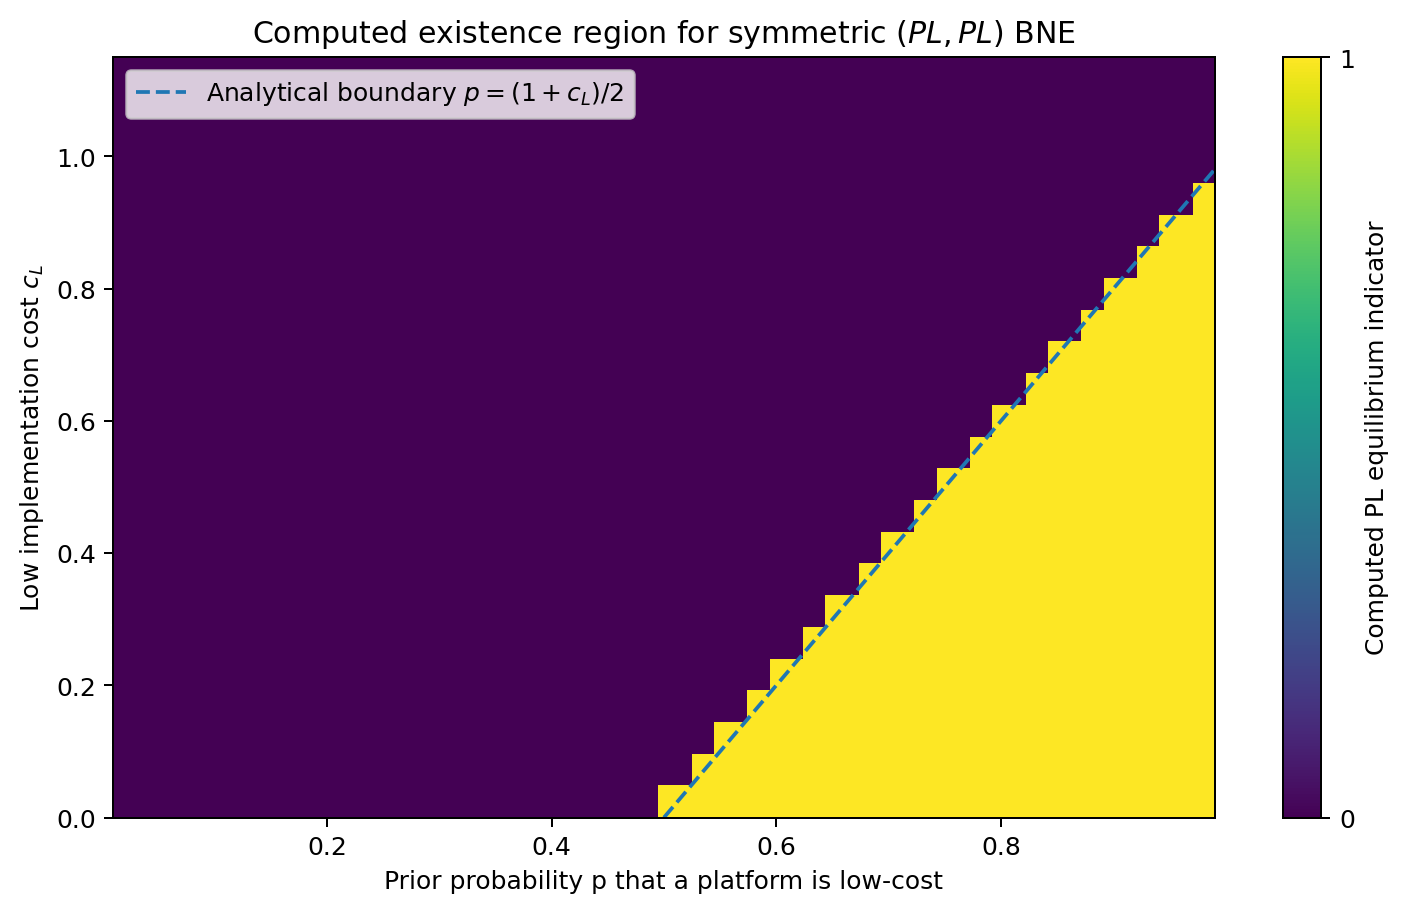

In [10]:
sensitivity = pd.read_csv(PROJECT_ROOT / "outputs" / "pl_equilibrium_sensitivity.csv")
print("Grid rows:", len(sensitivity))
print("Computational/analytical agreement:", bool(sensitivity["agreement"].all()))
display(Image(filename=str(PROJECT_ROOT / "figures" / "pl_equilibrium_threshold.png")))

## 14. Interpretation

Under the stated assumptions, the computation establishes that lock-in is always supportable as a pure equilibrium on the interior prior grid, while the type-contingent portability equilibrium becomes supportable at (p=0.6). For higher (p), both pure equilibria coexist. This is a benchmark-model prediction driven by private costs, beliefs, and strategic complementarity—not an empirical claim about actual AI-assistant markets.

## 15. Limitations

- Payoffs and costs are normalized rather than empirically calibrated.
- Portability is binary rather than partial.
- Platforms are symmetric apart from independently drawn private types.
- The independence assumption is not tested here.
- Equilibrium multiplicity is preserved, but equilibrium selection is unresolved.
- The mixed calculation is a symmetric type-specific benchmark, not a general catalog.
- Degenerate prior endpoints require separate treatment.
- User welfare is not modeled.
- No subsidy, certification, or other mechanism is modeled.
- The auction extension is not implemented.
- No behavioral or real-user evidence has been collected.

## 16. Reproducibility

From `ps2_memory_portability/`, regenerate all outputs with:

```bash
conda run -n cs206-ps2 python scripts/run_phase2.py
```

Run tests with:

```bash
conda run -n cs206-ps2 python -m unittest discover -s tests -v
```

Execute this notebook with:

```bash
conda run -n cs206-ps2 python scripts/execute_notebook.py
```

See `docs/reproducibility.md` for the tested environment and evidence boundaries.